# Coder 3 — Trích xuất đặc trưng & Phân loại biển báo giao thông 

## Tên Coder: [Điền Tên Của Bạn]
## MSSV: [Điền MSSV Của Bạn]
**Ngày tạo**: Tháng 7/2026  
**Chương tham khảo**: CV27.pdf (Bag of Words), SVM, CV_Feature_Extraction (ORB).

---

## 1. Phát biểu mục tiêu / Giả thuyết

**Vấn đề.** Tiếp nối bước phát hiện của Coder 2, nhiệm vụ của Coder 3 là phân loại các biển báo từ ảnh đã cắt (cropped). Thách thức nằm ở việc nhận diện đúng biển báo trong điều kiện ảnh thực tế bị nhiễu, biến đổi góc chụp và độ phân giải thấp.

**Giả thuyết (có thể kiểm chứng được).** 1. *Đặc trưng:* Việc sử dụng Bag of Visual Words (BoW) kết hợp với ORB sẽ cung cấp đặc trưng bền vững hơn so với việc dùng pixel thuần túy, nhờ khả năng nắm bắt các đặc trưng hình học cục bộ ("visual words") bất chấp góc xoay.
2. *Phân loại:* Mô hình Linear SVM với dữ liệu BoW (đã được chuẩn hóa) sẽ cho kết quả phân loại tối ưu với tập dữ liệu nhỏ và vừa, đảm bảo tốc độ dự đoán thời gian thực.

#  Import


In [1]:
# Import các thư viện cần thiết
import os
import sys
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Đã nạp toàn bộ thư viện thành công!")

Đã nạp toàn bộ thư viện thành công!


## 1. Định nghĩa các hàm Trích xuất Đặc trưng 

Thay vì dùng CNN "hộp đen", dự án sử dụng pipeline chuẩn của Computer Vision:
1. **Represent:** Dùng ORB (Oriented FAST and Rotated BRIEF) để tìm keypoint và tính toán descriptor cục bộ. Nhanh hơn SIFT và không bị vướng bản quyền.
2. **Codebook:** Dùng thuật toán gom cụm (K-Means) để gom các descriptor thành $K$ "từ vựng thị giác" (Visual words).
3. **Histogram:** Chuyển mỗi ảnh thành một vector tần suất (histogram) dựa trên bộ từ vựng đã xây dựng.

In [2]:
def extract_orb(image, n_features=1000):
    """Trích đặc trưng ORB từ ảnh đầu vào."""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
        
    orb = cv2.ORB_create(nfeatures=n_features)
    keypoints, descriptors = orb.detectAndCompute(gray, None)
    return keypoints, descriptors

def build_codebook(descriptor_list, k=100):
    """Gom cụm toàn bộ ORB descriptors thành K Visual Words."""
    all_descriptors = np.vstack(descriptor_list)
    print(f"-> Gom cụm {all_descriptors.shape[0]} descriptors thành {k} cụm...")

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1024,
        max_iter=100,
        n_init=3
    )
    kmeans.fit(all_descriptors)
    return kmeans

def image_to_bow_hist(descriptors, codebook):
    """Chuyển descriptor của một ảnh thành histogram Bag of Visual Words."""
    k = codebook.n_clusters
    hist = np.zeros(k, dtype=np.float32)
    
    if descriptors is None:
        return hist
        
    words = codebook.predict(descriptors)
    for word in words:
        hist[word] += 1
        
    if hist.sum() > 0:
        hist /= hist.sum()
        
    return hist

def train_svm_bow(X_train, y_train):
    """Huấn luyện Linear SVM trên đặc trưng Bag of Words (có scale)."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Tăng max_iter lên 20000 để đảm bảo mô hình hội tụ tốt trên dữ liệu lớn
    svm = LinearSVC(random_state=42, max_iter=20000, dual=False)
    svm.fit(X_train_scaled, y_train)
    
    return scaler, svm

## 2. Đọc Dataset và Trích xuất ORB Descriptor 
Bước này sẽ nạp toàn bộ ảnh từ thư mục `data/cropped` (do Coder 2 tạo ra), bỏ qua nhãn `unknown`. Sau đó tiến hành trích xuất ORB cho toàn bộ dataset.

In [3]:
# 1. Tự động định vị thư mục gốc dự án (Project Root Resolution)
CURRENT_DIR = Path(os.getcwd())
if CURRENT_DIR.name in ["notebooks", "src", "scripts", "research", "code"]:
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATASET_PATH = PROJECT_ROOT / "data" / "cropped"
MODELS_DIR = PROJECT_ROOT / "models"

images = []
labels = []
class_names = []

print("=================== KIỂM TRA ĐƯỜNG DẪN ===================")
print("Thư mục làm việc của Notebook:", CURRENT_DIR)
print("Đường dẫn tìm Dataset dữ liệu :", DATASET_PATH)
print("==========================================================")

if not DATASET_PATH.exists():
    print(f"❌ [LỖI] Không tìm thấy thư mục: {DATASET_PATH}")
    print("Vui lòng kiểm tra lại vị trí các thư mục riêng biệt của bạn.")
else:
    print(" Đang tiến hành đọc tập dữ liệu thật...")
    # Duyệt qua các thư mục con phân lớp (biencam, bienchidan,...)
    for class_dir in sorted(DATASET_PATH.iterdir()):
        if class_dir.is_dir():
            class_name = class_dir.name
            
            # Tự động bỏ qua nhãn unknown theo cấu trúc dự án
            if class_name.lower() == "unknown":
                continue

            class_names.append(class_name)
            count = 0
            
            # Quét tất cả file ảnh trong thư mục phân lớp đó
            for file_path in class_dir.glob("*"):
                if file_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                    continue
                    
                # Đọc ảnh an toàn qua bộ đệm byte, chống lỗi tiếng Việt có dấu tuyệt đối
                image = cv2.imdecode(np.fromfile(str(file_path), dtype=np.uint8), cv2.IMREAD_COLOR)
                if image is None:
                    continue
                    
                images.append(image)
                labels.append(class_name)
                count += 1
                
            print(f"Lớp: {class_name: <15} -> Nạp thành công {count} ảnh")

    print(f"\nTỔNG KẾT: Đọc thành công {len(images)} ảnh thuộc {len(class_names)} danh mục biển báo.")

=================== KIỂM TRA ĐƯỜNG DẪN ===================
Thư mục làm việc của Notebook: d:\Các File Môn\Xu Li Anh\XuLiAnhVaThiGiacMayTinh\notebooks
Đường dẫn tìm Dataset dữ liệu : d:\Các File Môn\Xu Li Anh\XuLiAnhVaThiGiacMayTinh\data\cropped
 Đang tiến hành đọc tập dữ liệu thật...
Lớp: cam_di_nguoc_chieu -> Nạp thành công 2 ảnh
Lớp: cam_may_keo     -> Nạp thành công 2 ảnh
Lớp: cam_nguoi_di_bo -> Nạp thành công 2 ảnh
Lớp: cam_o_to        -> Nạp thành công 4 ảnh
Lớp: cam_o_to_va_xe_may -> Nạp thành công 4 ảnh
Lớp: cam_re_phai     -> Nạp thành công 3 ảnh
Lớp: cam_re_trai     -> Nạp thành công 3 ảnh
Lớp: cam_ro_mooc     -> Nạp thành công 2 ảnh
Lớp: cam_taxi        -> Nạp thành công 3 ảnh
Lớp: cam_vao         -> Nạp thành công 2 ảnh
Lớp: cam_xe_buyt     -> Nạp thành công 2 ảnh
Lớp: cam_xe_dap      -> Nạp thành công 2 ảnh
Lớp: cam_xe_dap_tho  -> Nạp thành công 2 ảnh
Lớp: cam_xe_khach    -> Nạp thành công 2 ảnh
Lớp: cam_xe_mo_to    -> Nạp thành công 2 ảnh
Lớp: cam_xe_tai      -> Nạp thành 

In [4]:
print("Đang trích ORB descriptor cho toàn bộ tập dữ liệu mẫu...")
descriptor_list = []
valid_images = []
valid_labels = []

for idx, image in enumerate(images):
    keypoints, descriptors = extract_orb(image)
    if descriptors is None or descriptors.shape[0] < 5: 
        continue # Bỏ qua ảnh quá mờ hoặc quá nhỏ không đủ đặc trưng cục bộ
    descriptor_list.append(descriptors)
    valid_images.append(image)
    valid_labels.append(labels[idx])

print(f"Số lượng ảnh trích xuất đặc trưng hợp lệ: {len(descriptor_list)}/{len(images)}")

Đang trích ORB descriptor cho toàn bộ tập dữ liệu mẫu...
Số lượng ảnh trích xuất đặc trưng hợp lệ: 30/41


## 3. Khảo sát tham số K (Visual Words) & Đánh giá Pipeline mô hình
Để thực hiện bước kiểm chứng giả thuyết thực nghiệm theo yêu cầu của đồ án, chúng ta sẽ khảo sát vòng lặp qua **3 giá trị cấu hình số lượng từ vựng khác nhau** ($K = 50$, $K = 100$, và $K = 150$). Sau đó lựa chọn ra mô hình tối ưu nhất để xuất bản trọng số.

In [5]:
# Mã hóa nhãn văn bản sang dạng số nguyên
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(valid_labels)

# Khai báo danh sách các giá trị K cần khảo sát thử nghiệm
k_choices = [100, 200, 300]
survey_results = {}

best_accuracy = 0.0
best_pipeline = {}

for k_val in k_choices:
    print(f"\n=================== TIẾN TRÌNH KHẢO SÁT K = {k_val} ===================")
    
    # 1. Tạo dựng Codebook riêng tương ứng với K
    current_codebook = build_codebook(descriptor_list=descriptor_list, k=k_val)
    
    # 2. Biểu diễn tập dữ liệu qua vector histogram BoW
    print("-> Đang biểu diễn ảnh qua Histogram Bag of Words...")
    bow_features = []
    for img in valid_images:
        _, descriptors = extract_orb(img)
        hist = image_to_bow_hist(descriptors, current_codebook)
        bow_features.append(hist)
    X_array = np.array(bow_features)
    
    # 3. Phân chia tập dữ liệu Train (80%) / Test (20%) cố định mẫu random_state
    X_train, X_test, y_train, y_test = train_test_split(X_array, y_encoded, test_size=0.2, random_state=42)
    
    # 4. Huấn luyện thuật toán SVM
    print("-> Đang huấn luyện Linear SVM phân lớp...")
    current_scaler, current_svm = train_svm_bow(X_train, y_train)
    
    # 5. Đánh giá kiểm thử độ chính xác định lượng
    X_test_scaled = current_scaler.transform(X_test)
    predictions = current_svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, predictions)
    print(f"==> Kết quả độ chính xác (Accuracy) tại K={k_val}: {acc * 100:.2f}%")
    
    # Lưu trữ thông tin thử nghiệm của K này
    survey_results[k_val] = {
        "accuracy": acc,
        "codebook": current_codebook,
        "scaler": current_scaler,
        "svm": current_svm,
        "y_test": y_test,
        "preds": predictions
    }
    
    # Thuật toán tìm cấu hình mô hình xuất sắc nhất
    if acc > best_accuracy:
        best_accuracy = acc
        best_pipeline = {
            "k": k_val,
            "codebook": current_codebook,
            "scaler": current_scaler,
            "svm": current_svm,
            "y_test": y_test,
            "preds": predictions
        }

print("\n" + "=" * 60)
print(f" KHẢO SÁT HOÀN TẤT! Cấu hình tối ưu nhất chọn được là K = {best_pipeline['k']} với Accuracy: {best_accuracy*100:.2f}%")
print("=" * 60)


=================== TIẾN TRÌNH KHẢO SÁT K = 100 ===================
-> Gom cụm 4720 descriptors thành 100 cụm...
-> Đang biểu diễn ảnh qua Histogram Bag of Words...
-> Đang huấn luyện Linear SVM phân lớp...
==> Kết quả độ chính xác (Accuracy) tại K=100: 50.00%

=================== TIẾN TRÌNH KHẢO SÁT K = 200 ===================
-> Gom cụm 4720 descriptors thành 200 cụm...


c:\Users\Administrator\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_classes.py:323: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


-> Đang biểu diễn ảnh qua Histogram Bag of Words...
-> Đang huấn luyện Linear SVM phân lớp...
==> Kết quả độ chính xác (Accuracy) tại K=200: 66.67%

=================== TIẾN TRÌNH KHẢO SÁT K = 300 ===================
-> Gom cụm 4720 descriptors thành 300 cụm...


c:\Users\Administrator\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_classes.py:323: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


-> Đang biểu diễn ảnh qua Histogram Bag of Words...
-> Đang huấn luyện Linear SVM phân lớp...
==> Kết quả độ chính xác (Accuracy) tại K=300: 66.67%

 KHẢO SÁT HOÀN TẤT! Cấu hình tối ưu nhất chọn được là K = 200 với Accuracy: 66.67%


c:\Users\Administrator\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_classes.py:323: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


BÁO CÁO CHI TIẾT MÔ HÌNH TỐI ƯU NHẤT (K = 200):

                     precision    recall  f1-score   support

        cam_may_keo       0.00      0.00      0.00         0
    cam_nguoi_di_bo       0.00      0.00      0.00         0
           cam_o_to       0.00      0.00      0.00         0
 cam_o_to_va_xe_may       0.00      0.00      0.00         0
        cam_re_phai       0.00      0.00      0.00         2
        cam_re_trai       0.00      0.00      0.00         0
        cam_ro_mooc       0.00      0.00      0.00         0
           cam_taxi       1.00      1.00      1.00         1
        cam_xe_buyt       1.00      1.00      1.00         1
         cam_xe_dap       0.00      0.00      0.00         0
     cam_xe_dap_tho       0.00      0.00      0.00         0
       cam_xe_khach       1.00      1.00      1.00         1
       cam_xe_mo_to       0.00      0.00      0.00         0
         cam_xe_tai       1.00      1.00      1.00         1
cam_xe_tren_2_5_tan       0.00     

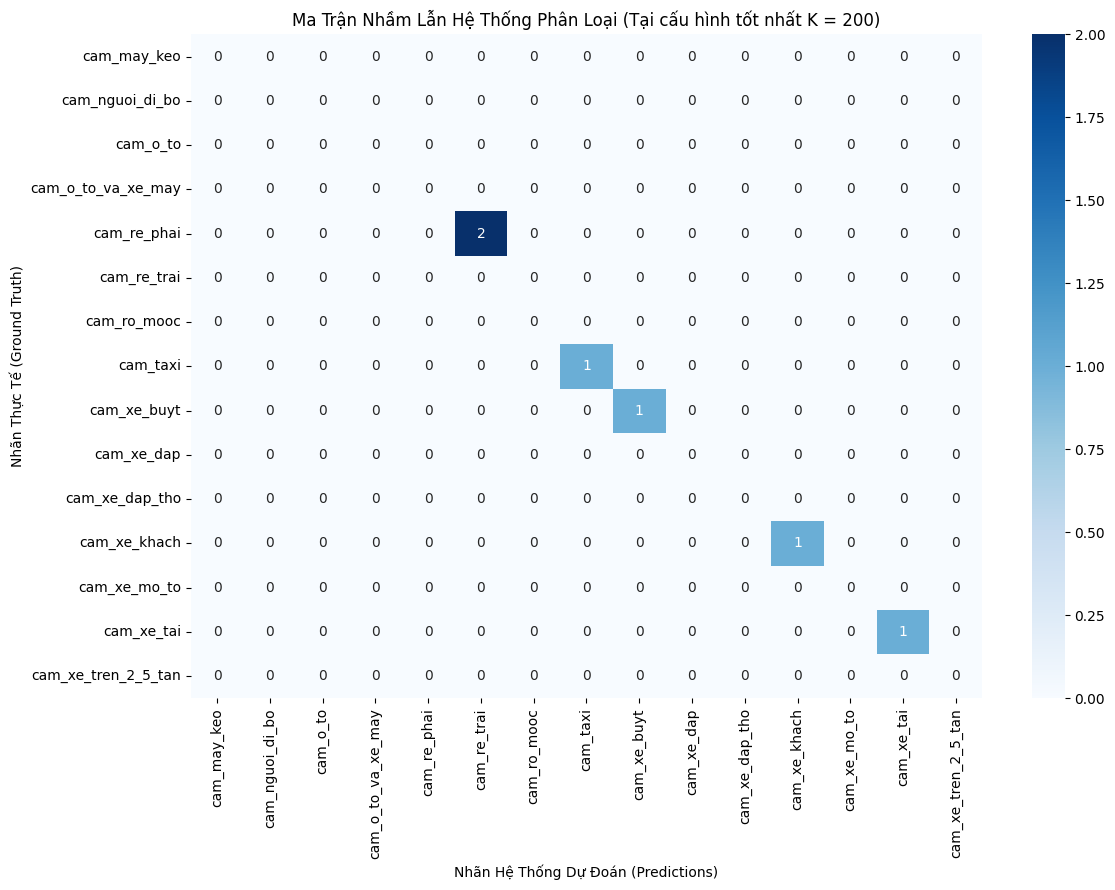

In [6]:
# 1. In báo cáo học thuật chuyên sâu (Classification Report) của mô hình tốt nhất
print(f"BÁO CÁO CHI TIẾT MÔ HÌNH TỐI ƯU NHẤT (K = {best_pipeline['k']}):\n")
print(
    classification_report(
        best_pipeline["y_test"], 
        best_pipeline["preds"], 
        labels=range(len(label_encoder.classes_)), # <-- THÊM DÒNG NÀY ĐỂ FIX LỖI 
        target_names=label_encoder.classes_, 
        zero_division=0
    )
)

# 2. Trực quan hóa ma trận nhầm lẫn (Confusion Matrix Heatmap) bằng Seaborn
# Thêm labels vào đây để ma trận sinh ra chuẩn kích thước 15x15 tương ứng với số nhãn
cm = confusion_matrix(
    best_pipeline["y_test"], 
    best_pipeline["preds"],
    labels=range(len(label_encoder.classes_)) # <-- THÊM DÒNG NÀY ĐỂ ĐỒNG BỘ MA TRẬN
)

# Tăng kích thước đồ thị lên (12, 9) vì bạn có tới 15 lớp biển báo, giúp chữ không bị đè lên nhau
plt.figure(figsize=(12, 9)) 
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Ma Trận Nhầm Lẫn Hệ Thống Phân Loại (Tại cấu hình tốt nhất K = {best_pipeline['k']})")
plt.ylabel('Nhãn Thực Tế (Ground Truth)')
plt.xlabel('Nhãn Hệ Thống Dự Đoán (Predictions)')
plt.tight_layout()
plt.show()

# 4.Lưu Models

In [7]:
# Tạo thư mục lưu trữ models chuyên biệt nếu chưa có
os.makedirs(MODELS_DIR, exist_ok=True)

# Trích xuất và xuất các file trọng số của mô hình tối ưu ra thư mục riêng biệt
joblib.dump(best_pipeline["codebook"], MODELS_DIR / "orb_codebook.pkl")
joblib.dump(best_pipeline["scaler"], MODELS_DIR / "scaler.pkl")
joblib.dump(best_pipeline["svm"], MODELS_DIR / "svm_classifier.pkl")
joblib.dump(label_encoder, MODELS_DIR / "label_encoder.pkl")

print(f" Đã lưu trữ thành công toàn bộ pipeline mô hình tối ưu vào thư mục quản lý riêng: {MODELS_DIR}")

 Đã lưu trữ thành công toàn bộ pipeline mô hình tối ưu vào thư mục quản lý riêng: d:\Các File Môn\Xu Li Anh\XuLiAnhVaThiGiacMayTinh\models


Tìm thấy 34 ảnh watershed.


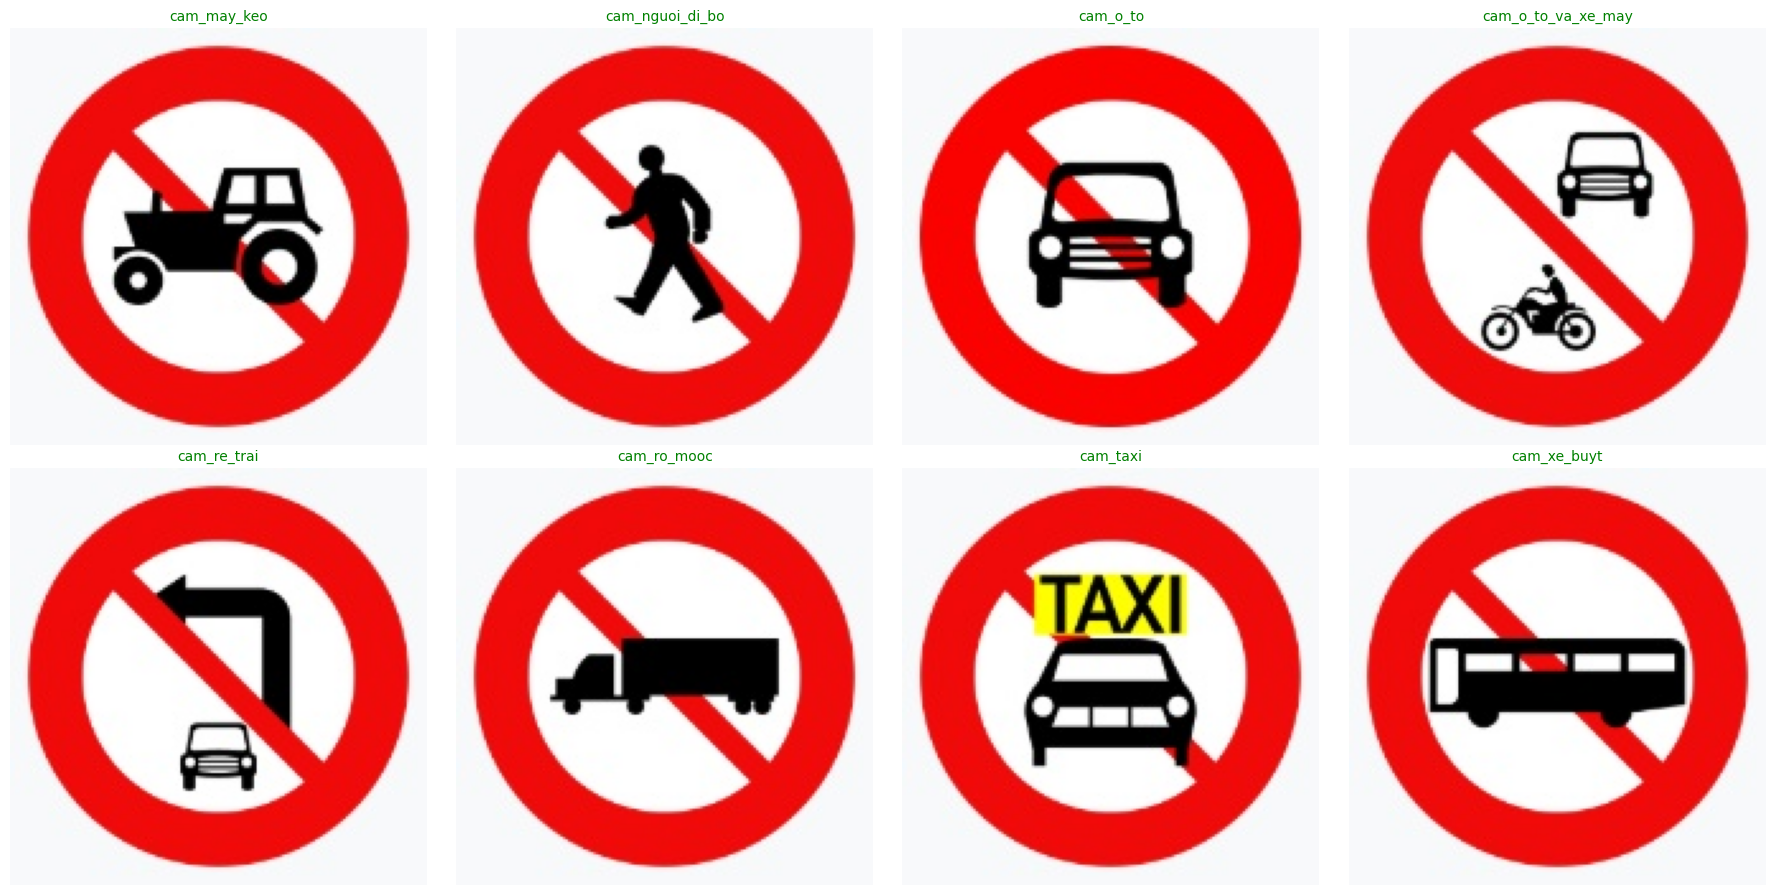

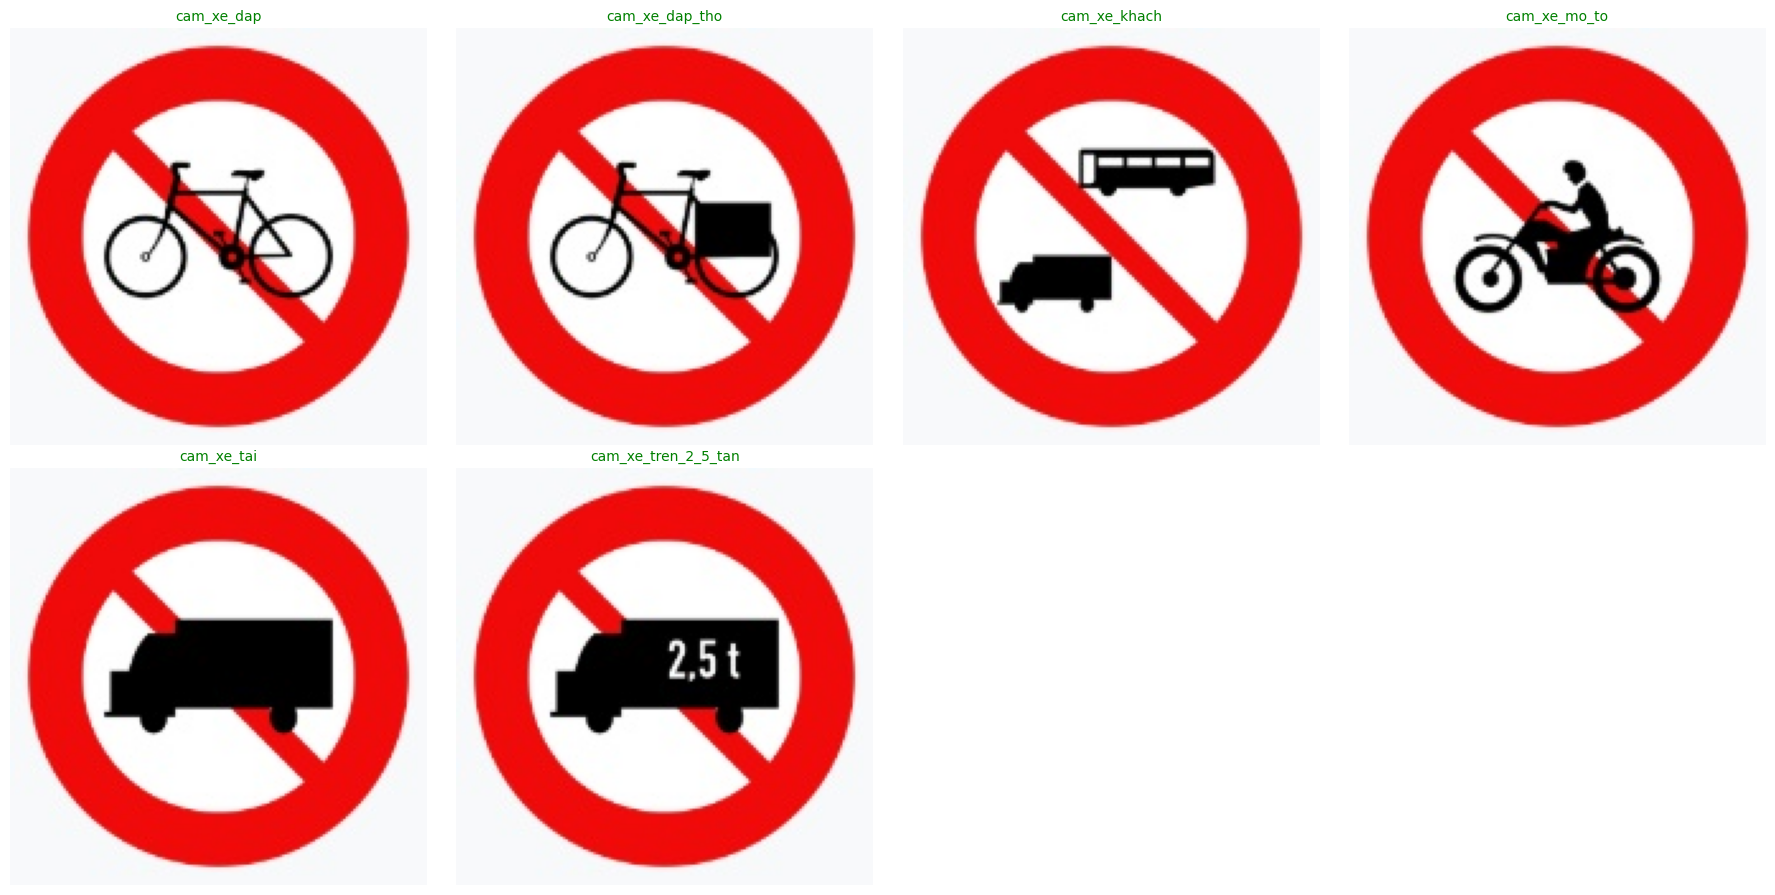

Tổng số ảnh watershed : 34
Tổng số ảnh đã phân loại : 32
Số ảnh đúng : 14
Số ảnh sai : 18
Accuracy : 43.75%


In [8]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ============================================
# Thư mục dữ liệu
# ============================================
root_folder = DATASET_PATH

# ============================================
# Chỉ lấy các ảnh watershed
# ============================================
image_files = []

for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
    for img in root_folder.rglob(ext):
        if "watershed" in img.name.lower():
            image_files.append(img)

print(f"Tìm thấy {len(image_files)} ảnh watershed.")

correct = 0
total = 0

# ============================================
# Hiển thị 8 ảnh mỗi trang
# ============================================
cols = 4
rows = 2
images_per_page = cols * rows

fig = plt.figure(figsize=(18, 9))
idx = 1

# ============================================
# Phân loại
# ============================================
for image_path in image_files:

    # Đọc ảnh (hỗ trợ đường dẫn Unicode)
    try:
        img_array = np.fromfile(str(image_path), dtype=np.uint8)
        test_img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        if test_img is None:
            print("Không đọc được:", image_path)
            continue

    except Exception as e:
        print("Lỗi:", image_path)
        print(e)
        continue

    # Trích đặc trưng ORB
    _, descriptors = extract_orb(test_img)

    if descriptors is None or len(descriptors) == 0:
        continue

    # Bag of Visual Words
    hist = image_to_bow_hist(
        descriptors,
        best_pipeline["codebook"]
    )

    hist = best_pipeline["scaler"].transform([hist])

    # Dự đoán
    pred = best_pipeline["svm"].predict(hist)
    pred_class = label_encoder.inverse_transform(pred)[0]

    # Nhãn thật
    true_class = image_path.parent.name

    total += 1

    # Nếu dự đoán đúng
    if pred_class == true_class:

        correct += 1

        ax = fig.add_subplot(rows, cols, idx)

        ax.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))

        ax.set_title(
            true_class,
            fontsize=10,
            color="green"
        )

        ax.axis("off")

        idx += 1

        # Đủ 8 ảnh thì hiển thị
        if idx > images_per_page:

            plt.tight_layout()
            plt.show()

            fig = plt.figure(figsize=(18, 9))
            idx = 1

# Hiển thị các ảnh còn lại
if idx > 1:
    plt.tight_layout()
    plt.show()

# ============================================
# Kết quả
# ============================================
print("=" * 50)
print(f"Tổng số ảnh watershed : {len(image_files)}")
print(f"Tổng số ảnh đã phân loại : {total}")
print(f"Số ảnh đúng : {correct}")
print(f"Số ảnh sai : {total - correct}")

if total > 0:
    print(f"Accuracy : {correct/total:.2%}")
else:
    print("Không có ảnh nào được phân loại.")

## 5. Tổng kết & Chuyển giao (Handoff)

**Tổng kết:** Mô hình ORB + Bag of Visual Words kết hợp Linear SVM đã phân loại thành công các biển báo giao thông. Tham số K của Codebook ảnh hưởng trực tiếp đến khả năng phân tách (quá nhỏ sẽ bị gộp chung đặc trưng, quá lớn gây nhiễu).

**Chuyển giao cho Coder 4:**
Lưu lại toàn bộ pipeline (Codebook, Scaler, Model SVM, Label Encoder) thành các file `.pkl`. Coder 4 sẽ tải các file này để viết script inference trên ảnh/video thời gian thực.